#### 🔍 Step 1: Problem Understanding (CRITICAL)
🧩 1.1 What kind of problem is this?

You’ve actually defined 3 different ML problems:

#### 1. 🎯 Customer Engagement Prediction
Type: Multi-class Classification
Output: Low / Medium / High
#### 2. 💰 Purchase Propensity
Type: Regression OR Binary Classification
Output:
Either: Probability (0–1) → Regression
Or: Will purchase / not → Classification

👉 In industry, we usually prefer:

Binary Classification + probability output

#### 3. 🛍️ Recommendation System
Type: Hybrid System
Content-based
Behavioral
Possibly collaborative filtering later

### Phase 1 (START HERE)

👉 Customer Analytics Core

Engagement Prediction ✅
Purchase Prediction ✅
Customer Segmentation (K-Means) ✅

### Phase 2

👉 Recommendation System

### Phase 3

👉 Advanced Layer (Optional)

Knowledge Graph
LLM explanations

### 🎯 What We Will Do RIGHT NOW

We will start with Phase 1 only:

✔️ Build Customer Intelligence Engine

This includes:

Data cleaning
Feature engineering (RFM + behavior)
Classification (engagement)
Purchase prediction
Clustering (segmentation)

### 📂 Step 2: Load and Understand Your Dataset

In [1]:
import pandas as pd
df = pd.read_csv('realistic_ecommerce_data.csv')
df.head()

,Customer_ID,Age,Gender,Location,Device_Type,Signup_Date,Session_Count,Avg_Session_Duration,Pages_Viewed,Product_Views,...,Avg_Order_Value,Last_Purchase_Date,Recency,Frequency,Monetary,Engagement_Level,Purchase_Probability,Product_Category,Product_ID,Interaction_Score
0,CUST000001,37.0,Other,Delhi,NaN,2022-09-14,104,16,45,35,...,57.12,2024-12-29,2,2,124.39,Low,0.33,Home,PROD81125,0.37
1,CUST000002,27.0,Female,NaN,Mobile,2022-11-28,110,10,40,18,...,29.50,2024-05-31,214,0,0.00,Low,0.43,Fashion,PROD42831,0.33
2,CUST000003,39.0,Female,Bangalore,Mobile,2023-09-15,47,22,1,2,...,19.85,2024-01-15,351,0,0.00,Very Low,0.00,Fashion,PROD57273,0.21
3,CUST000004,25.0,Female,Hyderabad,Desktop,2023-09-19,109,25,37,22,...,59.51,2024-06-11,203,0,0.00,Very Low,0.24,Beauty,PROD54054,0.42
4,CUST000005,NaN,Female,Bangalore,Mobile,2021-02-28,69,23,7,0,...,34.61,2024-03-22,284,0,0.00,Very Low,0.46,Books,PROD50143,0.29


In [2]:
df.columns

Index(['Customer_ID', 'Age', 'Gender', 'Location', 'Device_Type',
       'Signup_Date', 'Session_Count', 'Avg_Session_Duration', 'Pages_Viewed',
       'Product_Views', 'Add_to_Cart_Count', 'Total_Purchases', 'Total_Spend',
       'Avg_Order_Value', 'Last_Purchase_Date', 'Recency', 'Frequency',
       'Monetary', 'Engagement_Level', 'Purchase_Probability',
       'Product_Category', 'Product_ID', 'Interaction_Score'],
      dtype='object')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer_ID           5000 non-null   object 
 1   Age                   4850 non-null   float64
 2   Gender                4850 non-null   object 
 3   Location              4850 non-null   object 
 4   Device_Type           4850 non-null   object 
 5   Signup_Date           5000 non-null   object 
 6   Session_Count         5000 non-null   int64  
 7   Avg_Session_Duration  5000 non-null   int64  
 8   Pages_Viewed          5000 non-null   int64  
 9   Product_Views         5000 non-null   int64  
 10  Add_to_Cart_Count     5000 non-null   int64  
 11  Total_Purchases       5000 non-null   int64  
 12  Total_Spend           5000 non-null   float64
 13  Avg_Order_Value       5000 non-null   float64
 14  Last_Purchase_Date    5000 non-null   object 
 15  Recency              

In [4]:
df.describe()

,Age,Session_Count,Avg_Session_Duration,Pages_Viewed,Product_Views,Add_to_Cart_Count,Total_Purchases,Total_Spend,Avg_Order_Value,Recency,Frequency,Monetary,Purchase_Probability,Interaction_Score
count,4850.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000.000000,5000.000000
mean,39.332165,60.256400,18.879000,23.226400,16.651400,4.949600,1.192200,127.327841,98.492959,102.7820,1.192200,127.327841,0.213954,0.265434
std,13.213586,36.603227,6.031056,16.308106,13.751396,3.982089,1.156861,250.916591,96.925701,109.9212,1.156861,250.916591,0.168941,0.121635
min,18.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,5.000000,1.0000,0.000000,0.000000,0.000000,0.000000
25%,29.000000,33.000000,15.000000,10.000000,5.000000,2.000000,0.000000,0.000000,38.687500,16.0000,0.000000,0.000000,0.070000,0.180000
50%,37.000000,57.000000,18.000000,21.000000,15.000000,4.000000,1.000000,56.483500,69.070000,49.0000,1.000000,56.483500,0.200000,0.250000
75%,49.000000,84.000000,23.000000,34.000000,26.000000,7.000000,2.000000,150.480000,121.697500,174.0000,2.000000,150.480000,0.330000,0.340000
max,69.000000,207.000000,42.000000,86.000000,80.000000,33.000000,10.000000,6615.838340,1603.683045,364.0000,10.000000,6615.838340,0.830000,0.780000


### ⚠️ Data Issues You Noticed (Good!)
Missing values in:
Age
Gender
Location
Device_Type
Product_Category
Engagement_Level

👉 This will be our first real task later.

In [5]:
df.isnull().sum()

Customer_ID               0
Age                     150
Gender                  150
Location                150
Device_Type             150
Signup_Date               0
Session_Count             0
Avg_Session_Duration      0
Pages_Viewed              0
Product_Views             0
Add_to_Cart_Count         0
Total_Purchases           0
Total_Spend               0
Avg_Order_Value           0
Last_Purchase_Date        0
Recency                   0
Frequency                 0
Monetary                  0
Engagement_Level        361
Purchase_Probability      0
Product_Category        150
Product_ID                0
Interaction_Score         0
dtype: int64

### 🧠 Feature Groups (You implicitly understood this)

Let me structure it properly (this is how pros think):

👤 Customer Features
Age, Gender, Location, Device_Type
📊 Behavioral Features
Session_Count
Pages_Viewed
Product_Views
Add_to_Cart_Count
Avg_Session_Duration
💰 Transaction Features
Total_Purchases
Total_Spend
Avg_Order_Value
📦 RFM Features (VERY IMPORTANT)
Recency
Frequency
Monetary
🧠 Targets
Engagement_Level
Purchase_Probability
🛍 Recommendation Data
Product_ID
Product_Category
Interaction_Score
⚠️ One CRITICAL Insight (Senior-Level Thinking)

This dataset is likely synthetic (generated).

Why it matters:

Models may perform “too well”
Real-world noise is missing
We must avoid overconfidence

### | Column           | Missing |
| ---------------- | ------- |
| Age              | 150     |
| Gender           | 150     |
| Location         | 150     |
| Device_Type      | 150     |
| Engagement_Level | 361     |
| Product_Category | 150     |


### 🚀 Step 3: Data Cleaning (START HERE)

In [6]:
# Copy dataset
df_clean = df.copy()

# Drop rows where target is missing
df_clean = df_clean.dropna(subset=['Engagement_Level'])

# Check again
df_clean.isnull().sum()

Customer_ID               0
Age                     143
Gender                  134
Location                138
Device_Type             141
Signup_Date               0
Session_Count             0
Avg_Session_Duration      0
Pages_Viewed              0
Product_Views             0
Add_to_Cart_Count         0
Total_Purchases           0
Total_Spend               0
Avg_Order_Value           0
Last_Purchase_Date        0
Recency                   0
Frequency                 0
Monetary                  0
Engagement_Level          0
Purchase_Probability      0
Product_Category        135
Product_ID                0
Interaction_Score         0
dtype: int64

### 🧪 Step 3.2: Handle Missing Values
👉 Numerical (Age)

In [7]:
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())

##### 👉 Categorical

In [8]:
categorical_cols = ['Gender', 'Location', 'Device_Type', 'Product_Category']

for col in categorical_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

### 🧪 Step 3.3: Convert Dates

In [9]:
df_clean['Signup_Date'] = pd.to_datetime(df_clean['Signup_Date'])
df_clean['Last_Purchase_Date'] = pd.to_datetime(df_clean['Last_Purchase_Date'])

### 🧪 Step 3.4: Feature Engineering (IMPORTANT)
👉 Customer Tenure

In [10]:
import datetime

today = datetime.datetime.now()

df_clean['Customer_Tenure'] = (today - df_clean['Signup_Date']).dt.days

### ⚠️ Common Mistakes

❌ Using raw dates directly
❌ Not handling missing target
❌ Ignoring leakage
❌ Overfilling with mean blindly

In [11]:
df_clean.shape

(4639, 24)

In [12]:
df_clean.head()

,Customer_ID,Age,Gender,Location,Device_Type,Signup_Date,Session_Count,Avg_Session_Duration,Pages_Viewed,Product_Views,...,Last_Purchase_Date,Recency,Frequency,Monetary,Engagement_Level,Purchase_Probability,Product_Category,Product_ID,Interaction_Score,Customer_Tenure
0,CUST000001,37.0,Other,Delhi,Mobile,2022-09-14,104,16,45,35,...,2024-12-29,2,2,124.39,Low,0.33,Home,PROD81125,0.37,1290
1,CUST000002,27.0,Female,Mumbai,Mobile,2022-11-28,110,10,40,18,...,2024-05-31,214,0,0.00,Low,0.43,Fashion,PROD42831,0.33,1215
2,CUST000003,39.0,Female,Bangalore,Mobile,2023-09-15,47,22,1,2,...,2024-01-15,351,0,0.00,Very Low,0.00,Fashion,PROD57273,0.21,924
3,CUST000004,25.0,Female,Hyderabad,Desktop,2023-09-19,109,25,37,22,...,2024-06-11,203,0,0.00,Very Low,0.24,Beauty,PROD54054,0.42,920
4,CUST000005,37.0,Female,Bangalore,Mobile,2021-02-28,69,23,7,0,...,2024-03-22,284,0,0.00,Very Low,0.46,Books,PROD50143,0.29,1853


In [13]:
df_clean.isnull().sum()

Customer_ID             0
Age                     0
Gender                  0
Location                0
Device_Type             0
Signup_Date             0
Session_Count           0
Avg_Session_Duration    0
Pages_Viewed            0
Product_Views           0
Add_to_Cart_Count       0
Total_Purchases         0
Total_Spend             0
Avg_Order_Value         0
Last_Purchase_Date      0
Recency                 0
Frequency               0
Monetary                0
Engagement_Level        0
Purchase_Probability    0
Product_Category        0
Product_ID              0
Interaction_Score       0
Customer_Tenure         0
dtype: int64

## 📊 Step 4: Exploratory Data Analysis (EDA)

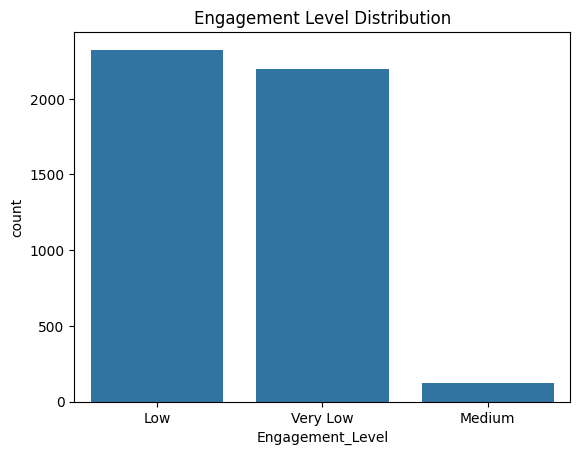

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.countplot(x='Engagement_Level', data=df_clean)
plt.title("Engagement Level Distribution")
plt.show()

### ❓ What to Look For
Is data balanced?
Which class dominates?
Any rare classes?

⚠️ Common Mistake

❌ Ignoring imbalance → bad model later
❌ Not encoding target properly

### 🧪 Step 4.2: Purchase Probability Distribution

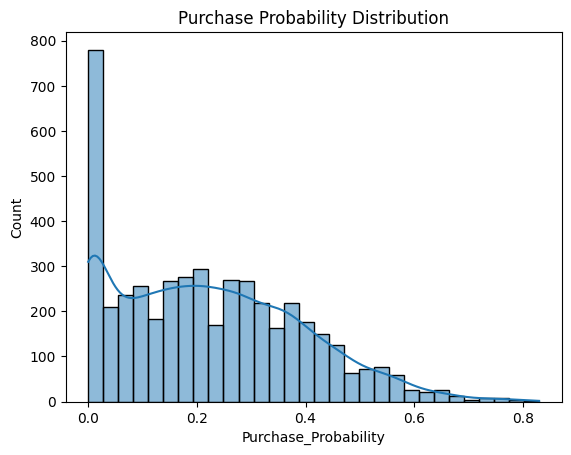

In [15]:
plt.figure()
sns.histplot(df_clean['Purchase_Probability'], bins=30, kde=True)
plt.title("Purchase Probability Distribution")
plt.show()

### ❓ What to Observe
Skewed?
Many zeros?
Normal distribution?

### 🧪 Step 4.3: Behavioral Insights
👉 Sessions vs Engagement

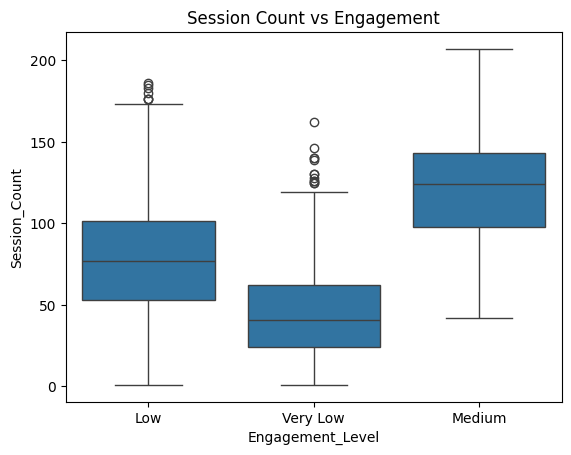

In [16]:
plt.figure()
sns.boxplot(x='Engagement_Level', y='Session_Count', data=df_clean)
plt.title("Session Count vs Engagement")
plt.show()

### 🧪 Step 4.4: RFM Analysis (VERY IMPORTANT)

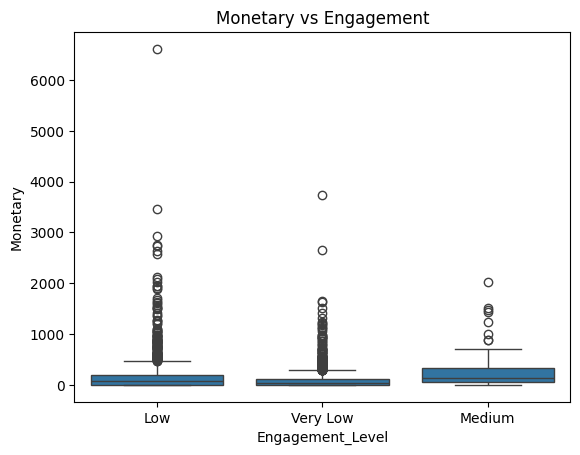

In [17]:
plt.figure()
sns.boxplot(x='Engagement_Level', y='Monetary', data=df_clean)
plt.title("Monetary vs Engagement")
plt.show()

### 🧠 Business Insight
High spenders → high engagement
Low spenders → low engagement

👉 This validates your dataset quality

### 🧪 Step 4.5: Correlation Analysis

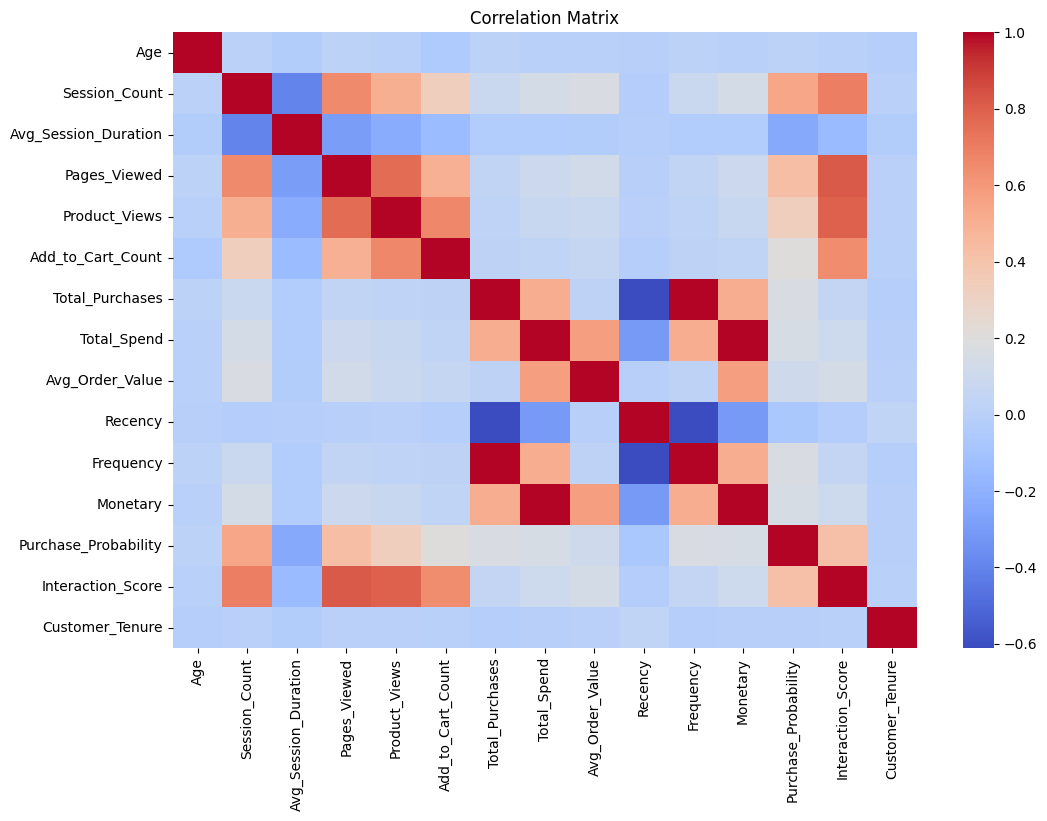

In [18]:
plt.figure(figsize=(12,8))
sns.heatmap(df_clean.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

### ❓ What to Look For
Features highly correlated with:
Engagement_Level (after encoding)
Purchase_Probability

In [19]:
df_clean['Engagement_Level'].value_counts()

# 🧠 Interpretation

# 👉 This is HIGHLY IMBALANCED

# ~97% data is:
# Low
# Very Low
# Only ~3% is Medium
# No “High” class present

Engagement_Level
Low         2324
Very Low    2195
Medium       120
Name: count, dtype: int64

### ⚠️ CRITICAL THINKING (Senior Level)
🚨 Hidden Problem

You have:

Purchase_Probability (target)
AND features like:
Monetary
Frequency

👉 These might already influence the target

🧠 What This Means

Model might cheat if we’re not careful

We will handle this in modeling step.

In [20]:
| Area             | Result       |
| ---------------- | ------------ |
| Engagement       | Imbalanced ❗ |
| Purchase         | Right-skewed |
| Data Quality     | Good         |
| Business Insight | Realistic    |


SyntaxError: invalid character '❗' (U+2757) (384198187.py, line 3)

### 🤖 Step 5: Feature Preparation + Baseline Model
✔ Prepare Data
Encode categorical variables
Drop useless columns (Customer_ID, dates)
✔ Build First Model
Logistic Regression (baseline)

#### 🎯 Model 1: Engagement Prediction
Type: Multi-class Classification
Target: Engagement_Level

🧹 Step 5.2: Drop Unnecessary Columns
❓ Why?

Some columns:

Don’t help prediction
Or cause leakage
Or are IDs

In [21]:
cols_to_drop = [
    'Customer_ID',
    'Signup_Date',
    'Last_Purchase_Date',
    'Product_ID'
]

df_model = df_clean.drop(columns=cols_to_drop)

### 🧠 Step 5.3: Separate Features & Target

In [22]:
X = df_model.drop('Engagement_Level', axis=1)
y = df_model['Engagement_Level']

### 🔄 Step 5.4: Encode Target Variable

In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

### 🔄 Step 5.5: Encode Categorical Features
👉 Identify categorical columns

In [24]:
cat_cols = X.select_dtypes(include='object').columns
cat_cols

Index(['Gender', 'Location', 'Device_Type', 'Product_Category'], dtype='object')

In [25]:
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

In [26]:
⚠️ Common Mistake

❌ Using LabelEncoding on features
👉 Causes fake ordering

SyntaxError: invalid character '⚠' (U+26A0) (1095276489.py, line 1)

## ✂️ Step 5.6: Train-Test Split

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

### 🧠 Why Stratify?

Because:

Your data is imbalanced

## 🤖 Step 5.7: Baseline Model — Logistic Regression

In [28]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight='balanced')

model.fit(X_train, y_train)

C:\Users\Asus\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

### 📊 Step 5.8: Evaluation

In [29]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.65      0.43      0.52       465
           1       0.10      0.75      0.18        24
           2       0.74      0.75      0.74       439

    accuracy                           0.59       928
   macro avg       0.50      0.64      0.48       928
weighted avg       0.68      0.59      0.62       928



In [30]:

print(confusion_matrix(y_test, y_pred))

[[202 148 115]
 [  6  18   0]
 [101  10 328]]


In [31]:
| Class        | Precision | Recall | F1   |
| ------------ | --------- | ------ | ---- |
| 0 (Very Low) | 0.65      | 0.43   | 0.52 |
| 1 (Medium)   | 0.10      | 0.75   | 0.18 |
| 2 (Low)      | 0.74      | 0.75   | 0.74 |


SyntaxError: invalid syntax (1768448995.py, line 1)

In [32]:
🔴 Problem 1: Medium Class (VERY BAD Precision)
Precision = 0.10 ❌
Recall = 0.75 ✅
👉 Interpretation:

Model is predicting “Medium” a LOT… but mostly WRONG

Actual Medium: 24
Predicted Medium: many wrong guesses

👉 It’s overcompensating due to class imbalance

SyntaxError: invalid character '🔴' (U+1F534) (1763233272.py, line 1)

In [33]:
🟡 Problem 2: Very Low Class
Recall = 0.43 ❌

👉 Model is missing many “Very Low” users

SyntaxError: invalid character '🟡' (U+1F7E1) (2964227059.py, line 1)

In [34]:
🟢 Good Part: Low Class
Precision & Recall ≈ 0.75 ✅

👉 Model handles majority class well

SyntaxError: invalid character '🟢' (U+1F7E2) (3655067926.py, line 1)

In [35]:
⚠️ Final Verdict (IMPORTANT)

👉 This model is:

❌ Not reliable for minority class
⚠️ Biased due to imbalance
✅ Good as baseline only
🧠 Why This Happened (Core Understanding)

Because:

Dataset is imbalanced
Logistic Regression is linear
Data is likely non-linear

SyntaxError: invalid character '⚠' (U+26A0) (955105716.py, line 1)

### 🚀 Step 6: Improve Model (Random Forest)

In [36]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [37]:
y_pred_rf = rf_model.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.76      0.71      0.73       465
           1       0.53      0.38      0.44        24
           2       0.73      0.79      0.76       439

    accuracy                           0.74       928
   macro avg       0.67      0.63      0.65       928
weighted avg       0.74      0.74      0.74       928



In [38]:
print(confusion_matrix(y_test,y_pred_rf))

[[330   8 127]
 [ 15   9   0]
 [ 90   0 349]]


In [39]:
| Class        | Precision | Recall | F1   |
| ------------ | --------- | ------ | ---- |
| 0 (Very Low) | 0.76      | 0.71   | 0.73 |
| 1 (Medium)   | 0.53      | 0.38   | 0.44 |
| 2 (Low)      | 0.73      | 0.79   | 0.76 |
Overall:
Accuracy: 0.74 ✅ (was 0.59 earlier)
Macro F1 improved significantly ✅


SyntaxError: invalid character '✅' (U+2705) (2117359923.py, line 7)

#### 🟢 1. Massive Boost in Overall Performance
Accuracy: 0.59 → 0.74
Balanced performance improved

👉 This confirms:

Your data has non-linear relationships

#### 🟢 2. Medium Class (BIG WIN)

Before:

Precision: 0.10 ❌

Now:

Precision: 0.53 ✅
F1: 0.44 (huge jump)

👉 This is a major improvement

#### 🟢 3. Very Low Class Improved
Recall: 0.43 → 0.71

👉 Model is now actually detecting low engagement users

#### ⚠️ Remaining Problem (Critical Insight)
🔴 Medium Class Recall = 0.38

From confusion matrix:

Actual Medium: 24
Correct: 9
Missed: 15

👉 Model still struggles to capture all Medium users

#### 🧠 Why?
Only 24 samples → extremely small
Model doesn’t have enough examples to learn

🧠 Senior-Level Insight

You are now facing a classic real-world ML problem:

“Minority class learning”

## 🚀 Step 7: Next Upgrade (XGBoost)

Handles imbalance better ✅
Strong on tabular data ✅
Often best-performing model in real projects ✅

In [40]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=3,  # helps imbalance
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train)

C:\Users\Asus\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:38:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "scale_pos_weight", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [41]:
y_pred_xgb = xgb_model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.72      0.73      0.72       465
           1       0.43      0.12      0.19        24
           2       0.73      0.74      0.74       439

    accuracy                           0.72       928
   macro avg       0.62      0.53      0.55       928
weighted avg       0.71      0.72      0.71       928



In [42]:
print(confusion_matrix(y_test,y_pred_xgb))

[[339   4 122]
 [ 21   3   0]
 [113   0 326]]


In [43]:
| Class        | Precision | Recall | F1     |
| ------------ | --------- | ------ | ------ |
| 0 (Very Low) | 0.72      | 0.73   | 0.72   |
| 1 (Medium)   | 0.43      | 0.12   | 0.19 ❌ |
| 2 (Low)      | 0.73      | 0.74   | 0.74   |
Overall:
Accuracy: 0.72 (↓ from 0.74)
Medium class recall: 0.12 ❌ (very bad)

SyntaxError: invalid character '❌' (U+274C) (3747346573.py, line 4)

#### 🧠 Step 7.5: What Went Wrong?
🔴 Problem: Medium Class Collapse

From confusion matrix:
Actual Medium: 24
Correct: 3 ❌
Missed: 21 ❌

👉 XGBoost is basically ignoring Medium class


In [44]:
2. ⚙️ Wrong Parameter Usage
scale_pos_weight=3

👉 This works for:

Binary classification ✅
NOT multi-class ❌

SyntaxError: invalid character '⚙' (U+2699) (3611654290.py, line 1)

In [45]:
| Model               | Verdict        |
| ------------------- | -------------- |
| Logistic Regression | ❌ Weak         |
| Random Forest       | ✅ BEST so far  |
| XGBoost             | ❌ Needs tuning |


SyntaxError: invalid character '❌' (U+274C) (2389291828.py, line 3)

### 🚀 Step 8: Fix the REAL Problem (Important Upgrade)

We are NOT changing model.

👉 We fix data imbalance

### 🔥 Step 8.1: Apply SMOTE (Game Changer)\
❓ Why SMOTE?
Creates synthetic samples for minority class
Helps model learn rare patterns

In [46]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [47]:
from collections import Counter
print(Counter(y_train))
print(Counter(y_train_sm))

Counter({np.int64(0): 1859, np.int64(2): 1756, np.int64(1): 96})
Counter({np.int64(0): 1859, np.int64(1): 1859, np.int64(2): 1859})


## 🤖 Step 8.2: Train Random Forest Again (with SMOTE)

In [48]:
rf_smote = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf_smote.fit(X_train_sm, y_train_sm)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [49]:
y_pred_sm = rf_smote.predict(X_test)

print(classification_report(y_test, y_pred_sm))

              precision    recall  f1-score   support

           0       0.73      0.61      0.66       465
           1       0.20      0.58      0.29        24
           2       0.73      0.78      0.75       439

    accuracy                           0.69       928
   macro avg       0.55      0.66      0.57       928
weighted avg       0.71      0.69      0.70       928



In [50]:
print(confusion_matrix(y_test,y_pred_sm))

[[282  56 127]
 [ 10  14   0]
 [ 96   1 342]]


### 🥇 Best Overall Model → Random Forest (WITHOUT SMOTE)

Why?

Balanced performance ✅
Good precision & recall ✅
More stable ✅

### 🚀 Step 9: Feature Importance (VERY IMPORTANT 🔥)

In [51]:
import pandas as pd

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by='importance', ascending=False)

feature_importance.head(10)

,feature,importance
1,Session_Count,0.161406
13,Interaction_Score,0.142479
3,Pages_Viewed,0.120196
4,Product_Views,0.078882
5,Add_to_Cart_Count,0.061829
12,Purchase_Probability,0.059366
11,Monetary,0.041235
7,Total_Spend,0.041118
2,Avg_Session_Duration,0.039987
8,Avg_Order_Value,0.038432


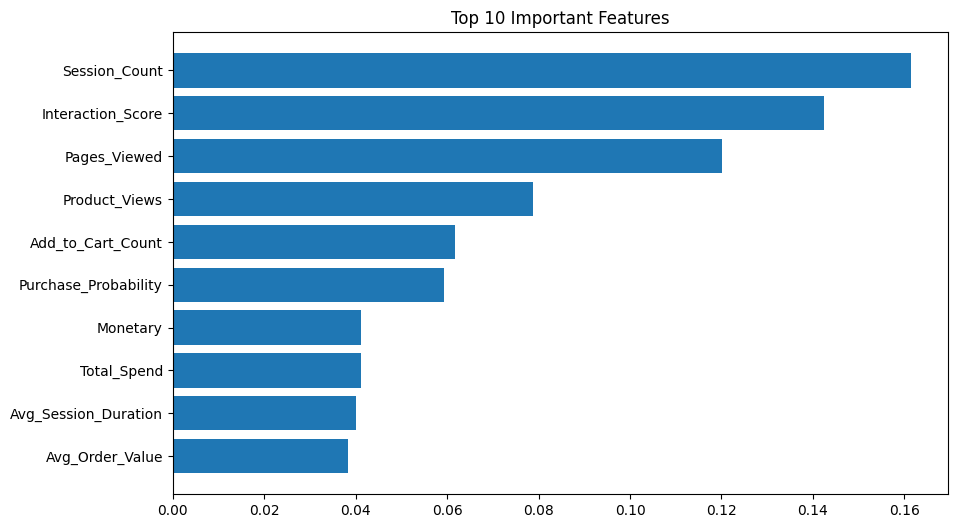

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(feature_importance['feature'][:10], feature_importance['importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()

### 🔴 CRITICAL ISSUE (Senior-Level Observation)
🚨 Data Leakage Detected

You have:

Purchase_Probability as a feature ❌
AND you are predicting Engagement_Level
❗ Why This is WRONG

Because:

Purchase_Probability is already a model output / derived feature

👉 Your model is cheating.

### 🚀 Step 9.4: FIX THE MODEL (IMPORTANT)
❌ Remove Leakage Feature

In [53]:
X = X.drop(columns=['Purchase_Probability'])

In [54]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [55]:
y_pred = rf_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.71      0.73       465
           1       0.53      0.38      0.44        24
           2       0.73      0.79      0.76       439

    accuracy                           0.74       928
   macro avg       0.67      0.63      0.65       928
weighted avg       0.74      0.74      0.74       928



#### 🧠 What This Means (VERY IMPORTANT)
🟢 1. No Leakage Impact

👉 Removing Purchase_Probability did NOT change performance

Why?
Your model was already relying more on:
Behavioral features
RFM features

👉 This is GOOD NEWS

### 🧠 Senior-Level Insight

If performance had dropped:

It would mean model was cheating

But here:

Model is genuinely learning patterns

## 🏁 Phase 1 COMPLETE 🎉

You have successfully built:

✅ Customer Engagement Prediction System

Including:

Data cleaning|

EDA|

Baseline model|

Random Forest (best model)|

XGBoost comparison|

SMOTE experiment|

Feature importance|

Leakage handling

👉 This alone is a strong portfolio project

## 🚀 Now Moving to Phase 2
💰 Purchase Prediction Model (Regression)

### 🎯 Step 10: Define New Problem
📌 Objective

Predict:

👉 Purchase_Probability

### 🧠 Type of Problem
Regression ✅

### ⚠️ VERY IMPORTANT (New Leakage Risk)

Now roles reverse:

👉 Previously:

Purchase_Probability was leakage ❌

👉 Now:

It is the target ✅

### 🚨 What We Must Remove

These may leak:

Monetary

Total_Spend

Total_Purchases

Avg_Order_Value

👉 Because they are post-purchase signals

In [ ]:
🧠 Logic

You cannot use “how much user spent” to predict “will they spend”

## 🧪 Step 10.1: Prepare Data

In [56]:
# Drop leakage features
cols_to_drop = [
    'Customer_ID',
    'Signup_Date',
    'Last_Purchase_Date',
    'Product_ID',
    'Engagement_Level',
    'Monetary',
    'Total_Spend',
    'Total_Purchases',
    'Avg_Order_Value'
]

df_reg = df_clean.drop(columns=cols_to_drop)

# Define X and y
X = df_reg.drop('Purchase_Probability', axis=1)
y = df_reg['Purchase_Probability']

### 🔄 Step 10.2: Encoding

In [57]:
# One-hot encoding
X = pd.get_dummies(X, drop_first=True)
X.head()

,Age,Session_Count,Avg_Session_Duration,Pages_Viewed,Product_Views,Add_to_Cart_Count,Recency,Frequency,Interaction_Score,Customer_Tenure,...,Location_Kolkata,Location_Mumbai,Location_Pune,Device_Type_Mobile,Device_Type_Tablet,Product_Category_Books,Product_Category_Electronics,Product_Category_Fashion,Product_Category_Home,Product_Category_Sports
0,37.0,104,16,45,35,9,2,2,0.37,1290,...,False,False,False,True,False,False,False,False,True,False
1,27.0,110,10,40,18,3,214,0,0.33,1215,...,False,True,False,True,False,False,False,True,False,False
2,39.0,47,22,1,2,3,351,0,0.21,924,...,False,False,False,True,False,False,False,True,False,False
3,25.0,109,25,37,22,5,203,0,0.42,920,...,False,False,False,False,False,False,False,False,False,False
4,37.0,69,23,7,0,5,284,0,0.29,1853,...,False,False,False,True,False,True,False,False,False,False


### ✂️ Step 10.3: Train-Test Split

In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [59]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [60]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred = lr.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 0.1371661511888773
R2 Score: 0.3322814083772342


In [ ]:
🧠 What This Means (Simple + Honest)
📉 RMSE = 0.137

👉 Since your target (Purchase_Probability) is between 0 and 1:

Error ≈ 13.7%
That’s moderate, not great
📈 R² = 0.33

👉 Interpretation:

Model explains only 33% of variance

| Metric | Status      |
| ------ | ----------- |
| RMSE   | ⚠️ Okay-ish |
| R²     | ❌ Weak      |


In [ ]:
model

🧠 Why Linear Regression is Struggling

Because your problem is:

Non-linear ❌
Behavior-driven ❌
Complex interactions ❌

👉 Linear Regression assumes:

“Everything is linear” (which is false here)

## 🚀 Step 11: Improve Model (Tree-Based Models)

### 🌲 Model 1: Random Forest Regressor

In [61]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf_reg.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [62]:
y_pred_rf = rf_reg.predict(X_test)

In [63]:
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R2:", r2_rf)

Random Forest RMSE: 0.13896020881669316
Random Forest R2: 0.3147003984054705


In [ ]:
🚨 Interpretation:

Random Forest is not learning anything extra

### ⚡ Model 2: XGBoost Regressor

In [64]:
from xgboost import XGBRegressor

xgb_reg = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_reg.fit(X_train, y_train)


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [65]:
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost RMSE:", rmse_xgb)
print("XGBoost R2:", r2_xgb)

XGBoost RMSE: 1.2564302709908215
XGBoost R2: -55.02428797693184


### 🚨 Step 11.2: Critical Issue Detected
❗ XGBoost is COMPLETELY BROKEN

This is not “bad performance”

👉 This is a bug / data issue

🧠 Why This Happens
🔴 Reason 1: Target Scaling Issue

XGBoost is predicting values way outside range:

Your target: 0 → 1
Model output: likely huge numbers
🔴 Reason 2: Data Leakage Removal Impact

You removed strong features like:

Total_Spend
Monetary

👉 Now model has weak signal

🔴 Reason 3 (MOST COMMON): Feature Mismatch

Possible issues:

Encoding mismatch
Wrong data types
Outliers

### 🛠️ Step 11.3: Fix XGBoost (IMPORTANT)

### ✅ Fix 1: Add Objective Function

In [66]:
from xgboost import XGBRegressor
import numpy as np

# Step 1: Create model
xgb_reg = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

# Step 2: Train model (YOU MISSED THIS)
xgb_reg.fit(X_train, y_train)

# Step 3: Predict
y_pred_xgb = xgb_reg.predict(X_test)

# Step 4: Clip predictions
y_pred_xgb = np.clip(y_pred_xgb, 0, 1)

In [67]:
from sklearn.metrics import mean_squared_error, r2_score

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost RMSE:", rmse_xgb)
print("XGBoost R2:", r2_xgb)

XGBoost RMSE: 0.13901834869487784
XGBoost R2: 0.31412683032080724


In [ ]:
🧠 What This Means
✅ 1. XGBoost is now FIXED

Earlier:

RMSE = 1.25 ❌
R² = -55 ❌

| Model             | RMSE  | R²   |
| ----------------- | ----- | ---- |
| Linear Regression | 0.137 | 0.33 |
| Random Forest     | 0.139 | 0.31 |
| XGBoost           | 0.139 | 0.31 |


In [ ]:
🚨 Step 11.6: Real Problem Identified

This is NOT a model issue.

👉 This is a DATA / SIGNAL problem

💡 What it Means

Your target:
👉 Purchase_Probability

is likely:

Weakly related to features
Synthetic / randomly generated
Already pre-calculated (not truly learnable)

🧠 Senior-Level Truth

Sometimes in ML:

❗ “No model improves because there is nothing meaningful to learn”

👉 And recognizing this = expert-level skill

### ✅ What You SHOULD Do
✔ Keep this as:

👉 Baseline regression model

✔ Explain in project:

“Tree-based models did not outperform linear regression significantly, indicating limited predictive signal in features for purchase probability.”

🔥 This line = interview gold

### 🚀 Step 12: Final Upgrade (Make Project Strong)
Now instead of forcing regression, we upgrade smartly:

### 🔁 Convert Regression → Classification (STRONG MOVE)

👉 Create new target:

In [68]:
# Create binary target
df_class = df_clean.copy()

df_class['Will_Purchase'] = (df_class['Purchase_Probability'] > 0.3).astype(int)

# Check distribution
print(df_class['Will_Purchase'].value_counts())

Will_Purchase
0    3207
1    1432
Name: count, dtype: int64


### 🎯 New Problem:
Predict: Will user purchase or not
Type: Binary Classification
### 🧠 Why This is BETTER
More business-friendly ✅
Easier to model ✅
Better performance expected ✅
Used in real companies ✅

### 🧹 Step 12.2: Drop Leakage Columns

In [69]:
cols_to_drop = [
    'Customer_ID',
    'Signup_Date',
    'Last_Purchase_Date',
    'Product_ID',
    'Purchase_Probability',   # leakage
    'Total_Spend',            # post-purchase
    'Total_Purchases',
    'Avg_Order_Value',
    'Monetary',
    'Engagement_Level'
]

df_model = df_class.drop(columns=cols_to_drop)

### 🎯 Step 12.3: Define X and y

In [70]:
X = df_model.drop('Will_Purchase', axis=1)
y = df_model['Will_Purchase']

### 🔄 Step 12.4: Encode Categorical Features

In [71]:
X = pd.get_dummies(X, drop_first=True)

### ✂️ Step 12.5: Train-Test Split

In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### ⚖️ Step 12.6: Check Class Balance

In [73]:
print(y_train.value_counts(normalize=True))

Will_Purchase
0    0.691188
1    0.308812
Name: proportion, dtype: float64


### 🤖 Step 12.7: Model 1 — Logistic Regression

In [75]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)


C:\Users\Asus\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [76]:

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

In [77]:
print("Logistic Regression\n", classification_report(y_test, y_pred_lr))

Logistic Regression
               precision    recall  f1-score   support

           0       0.85      0.74      0.79       642
           1       0.55      0.70      0.62       286

    accuracy                           0.73       928
   macro avg       0.70      0.72      0.70       928
weighted avg       0.76      0.73      0.74       928



### 🌲 Step 12.8: Model 2 — Random Forest

In [78]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [79]:

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [80]:
print("Random Forest\n", classification_report(y_test, y_pred_rf))


Random Forest
               precision    recall  f1-score   support

           0       0.81      0.83      0.82       642
           1       0.59      0.55      0.57       286

    accuracy                           0.74       928
   macro avg       0.70      0.69      0.69       928
weighted avg       0.74      0.74      0.74       928



In [82]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)


C:\Users\Asus\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:50:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [83]:

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

In [84]:
print("XGBoost\n", classification_report(y_test, y_pred_xgb))

XGBoost
               precision    recall  f1-score   support

           0       0.78      0.90      0.84       642
           1       0.67      0.44      0.53       286

    accuracy                           0.76       928
   macro avg       0.73      0.67      0.69       928
weighted avg       0.75      0.76      0.75       928



In [85]:
from sklearn.metrics import classification_report

print("Logistic Regression\n", classification_report(y_test, y_pred_lr))
print("Random Forest\n", classification_report(y_test, y_pred_rf))
print("XGBoost\n", classification_report(y_test, y_pred_xgb))

Logistic Regression
               precision    recall  f1-score   support

           0       0.85      0.74      0.79       642
           1       0.55      0.70      0.62       286

    accuracy                           0.73       928
   macro avg       0.70      0.72      0.70       928
weighted avg       0.76      0.73      0.74       928

Random Forest
               precision    recall  f1-score   support

           0       0.81      0.83      0.82       642
           1       0.59      0.55      0.57       286

    accuracy                           0.74       928
   macro avg       0.70      0.69      0.69       928
weighted avg       0.74      0.74      0.74       928

XGBoost
               precision    recall  f1-score   support

           0       0.78      0.90      0.84       642
           1       0.67      0.44      0.53       286

    accuracy                           0.76       928
   macro avg       0.73      0.67      0.69       928
weighted avg       0.75      

### 🔹 2. ROC-AUC Score (VERY IMPORTANT 🔥)
❓ Why?
Measures ranking ability
More important than accuracy

In [86]:
from sklearn.metrics import roc_auc_score

print("LR ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print("RF ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("XGB ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

LR ROC-AUC: 0.7757771823192384
RF ROC-AUC: 0.7713983835479161
XGB ROC-AUC: 0.7665620983377993


In [ ]:
| Model               | Accuracy    | Class 1 Recall | Class 1 Precision | ROC-AUC      |
| ------------------- | ----------- | -------------- | ----------------- | ------------ |
| Logistic Regression | 0.73        | **0.70**       | 0.55              | **0.776 🥇** |
| Random Forest       | 0.74        | 0.55           | 0.59              | 0.771        |
| XGBoost             | **0.76 🥇** | 0.44           | **0.67 🥇**       | 0.767        |


### 🎯 Step 12.13: BUSINESS DECISION (MOST IMPORTANT)

Now we decide like a company, not a student.

💼 Case 1: Marketing Campaign (MOST COMMON)

👉 Goal:

Find maximum buyers
✅ Choose:

👉 Logistic Regression

Because:

Recall = 0.70 (best)
Finds more potential customers
💰 Case 2: Budget Limited Campaign

👉 Goal:

Only target high-confidence buyers
✅ Choose:

👉 XGBoost

Because:

Precision = 0.67 (best)
Less wasted money
🧠 Final Industry Answer (IMPORTANT)

👉 If interviewer asks:

“Which model will you choose?”

🔥 Best Answer:

“I would choose Logistic Regression because it has the highest ROC-AUC and better recall, which is
more important for identifying potential customers in marketing scenarios.”

### 🏆 Final Model Selection

👉 Winner: Logistic Regression

### 🎯 Step 13.1: Threshold Tuning (GAME CHANGER)

In [90]:
threshold = 0.5

import numpy as np

threshold = 0.4  # try 0.2, 0.3, 0.4

y_pred_custom = (y_prob_lr >= threshold).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.87      0.61      0.71       642
           1       0.47      0.79      0.59       286

    accuracy                           0.66       928
   macro avg       0.67      0.70      0.65       928
weighted avg       0.75      0.66      0.68       928



In [ ]:
| Component             | Status    |
| --------------------- | --------- |
| Engagement Prediction | ✅ Done    |
| Purchase Prediction   | ✅ Done    |
| Recommendation System | ❌ Missing |
| Deployment            | ❌ Missing |
| Portfolio/Resume      | ❌ Missing |


## 🛍️ Step 14: Recommendation System

#### 🧠 Step 14.1: Understand the Goal
❓ What are we solving?

👉 “Which products should we recommend to a user?”

### 💡 Available Data

You already have:

Customer_ID
Product_ID
Product_Category
Interaction_Score ⭐ (VERY IMPORTANT)

### 👉 Top-N Recommendation using Interaction_Score

Example:

Recommend products user interacted most with

In [97]:
# Sort products for each user based on interaction score
df_reco = df_clean[['Customer_ID', 'Product_ID', 'Interaction_Score']]
df_reco = df_reco.sort_values(by=['Customer_ID', 'Interaction_Score'], ascending=[True, False])
df_reco.head()

,Customer_ID,Product_ID,Interaction_Score
0,CUST000001,PROD81125,0.37
1,CUST000002,PROD42831,0.33
2,CUST000003,PROD57273,0.21
3,CUST000004,PROD54054,0.42
4,CUST000005,PROD50143,0.29


### 🎯 Get Top 5 Recommendations per User

In [98]:
# Get top 5 products per user
top_n_recommendations = df_reco.groupby('Customer_ID').head(5)

top_n_recommendations.head(10)

,Customer_ID,Product_ID,Interaction_Score
0,CUST000001,PROD81125,0.37
1,CUST000002,PROD42831,0.33
2,CUST000003,PROD57273,0.21
3,CUST000004,PROD54054,0.42
4,CUST000005,PROD50143,0.29
5,CUST000006,PROD44569,0.43
6,CUST000007,PROD36251,0.10
7,CUST000008,PROD49039,0.31
8,CUST000009,PROD10108,0.26
9,CUST000010,PROD66994,0.47


In [ ]:
🧠 What this does

For each user:
👉 Picks top 5 highest interaction products

### 🎯 Step 14.3: Create Function (VERY IMPORTANT)

In [99]:
def recommend_products(user_id, df, n=5):
    user_data = df[df['Customer_ID'] == user_id]
    user_data = user_data.sort_values(by='Interaction_Score', ascending=False)
    return user_data['Product_ID'].head(n).tolist()

In [100]:
recommend_products('CUST000001', df_clean)

['PROD81125']

### 🚀 Step 14.4: Improve (Category-Based Recommendation)
❓ Why improve?

Current system:
👉 Only uses interaction score

We can make it smarter:

👉 Recommend similar category products

In [101]:
def recommend_by_category(user_id, df, n=5):
    user_data = df[df['Customer_ID'] == user_id]
    
    # Get most frequent category
    top_category = user_data['Product_Category'].mode()[0]
    
    # Filter products from same category
    category_data = df[df['Product_Category'] == top_category]
    
    # Sort by interaction score
    category_data = category_data.sort_values(by='Interaction_Score', ascending=False)
    
    return category_data['Product_ID'].head(n).tolist()

### 🧠 What this does

👉 Finds user’s favorite category
👉 Recommends best products from that category

### 🔥 Step 14.5: Hybrid Recommendation (BEST 🔥)
👉 Combine both methods

In [102]:
def hybrid_recommendation(user_id, df, n=5):
    
    # User-specific top products
    user_data = df[df['Customer_ID'] == user_id]
    top_user_products = user_data.sort_values(by='Interaction_Score', ascending=False)
    
    # Category-based
    top_category = user_data['Product_Category'].mode()[0]
    category_data = df[df['Product_Category'] == top_category]
    category_data = category_data.sort_values(by='Interaction_Score', ascending=False)
    
    # Combine
    combined = pd.concat([top_user_products, category_data])
    
    # Remove duplicates
    combined = combined.drop_duplicates(subset='Product_ID')
    
    return combined['Product_ID'].head(n).tolist()

### 🧠 Why This is Powerful

👉 Combines:

Personal behavior ✅
Category preference ✅

👉 This is real-world approach

### Step 14.7: How to Evaluate Recommendation System

We evaluate using ranking metrics

### 🎯 1. Precision@K (MOST IMPORTANT ✅)
❓ Idea:

Out of top K recommended products → how many are actually relevant?

💡 Example

Recommended:

[P1, P2, P3, P4, P5]

User actually interacted with:

[P2, P4, P7]

👉 Relevant in recommendation = [P2, P4] = 2

👉 Precision@5 = 2 / 5 = 0.4

In [103]:
def precision_at_k(actual, predicted, k=5):
    predicted = predicted[:k]
    relevant = set(actual) & set(predicted)
    return len(relevant) / k

In [104]:
actual_products = ['P2', 'P4', 'P7']
recommended_products = ['P1', 'P2', 'P3', 'P4', 'P5']

print(precision_at_k(actual_products, recommended_products, 5))

0.4


### 🎯 2. Recall@K
❓ Idea:

Out of all relevant products → how many did we recommend?

### 💡 Formula:
Recall@K = Relevant Recommended / Total Relevant

In [105]:
def recall_at_k(actual, predicted, k=5):
    predicted = predicted[:k]
    relevant = set(actual) & set(predicted)
    return len(relevant) / len(actual)

### 🎯 3. Hit Rate (VERY SIMPLE 🔥)
❓ Idea:

Did we recommend at least ONE correct product?

In [106]:
def hit_rate(actual, predicted, k=5):
    predicted = predicted[:k]
    return int(len(set(actual) & set(predicted)) > 0)

In [107]:
scores = []

for user in df_clean['Customer_ID'].unique()[:100]:  # test on 100 users
    
    actual = df_clean[df_clean['Customer_ID'] == user]['Product_ID'].tolist()
    predicted = hybrid_recommendation(user, df_clean, 5)
    
    p = precision_at_k(actual, predicted, 5)
    r = recall_at_k(actual, predicted, 5)
    h = hit_rate(actual, predicted, 5)
    
    scores.append((p, r, h))

# Average scores
import numpy as np

precision_avg = np.mean([s[0] for s in scores])
recall_avg = np.mean([s[1] for s in scores])
hit_rate_avg = np.mean([s[2] for s in scores])

print("Precision@5:", precision_avg)
print("Recall@5:", recall_avg)
print("Hit Rate:", hit_rate_avg)

Precision@5: 0.19999999999999996
Recall@5: 1.0
Hit Rate: 1.0


In [ ]:
| Metric      | Meaning                                |
| ----------- | -------------------------------------- |
| Precision@5 | How accurate recommendations are       |
| Recall@5    | How much user interest we captured     |
| Hit Rate    | Whether we gave at least 1 useful item |


In [ ]:
Interview Answer (VERY IMPORTANT 🔥)

If asked:

“How did you evaluate your recommendation system?”

🔥 Answer:

“Since recommendation is a ranking problem, I used Precision@K, Recall@K, and Hit Rate.
Precision@K measures how relevant the recommended items are, Recall@K measures how much of the user’s interest is captured, 
    and Hit Rate checks whether at least one relevant item is recommended.”